In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
# import arviz as az

import h5py
# import glob

import sxs

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import ringdown as rd

In [3]:
t0 = 1126259462.423
ra = 1.952318922
dec = -1.26967171703
psi = 0.824043851821

In [6]:
fit = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1155/mtot330/220_SXS_BBH_1155_fmin10Hz_ppSNR20_mtot330_inclined/engine/1126259462.423000/config.ini')

In [27]:
wfs = {i: pd.read_hdf(f'/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot330/SXS_BBH_1155_fmin10Hz_ppSNR20_mtot330_inclined_{i}.hdf5', key=i) for i in fit.ifos}

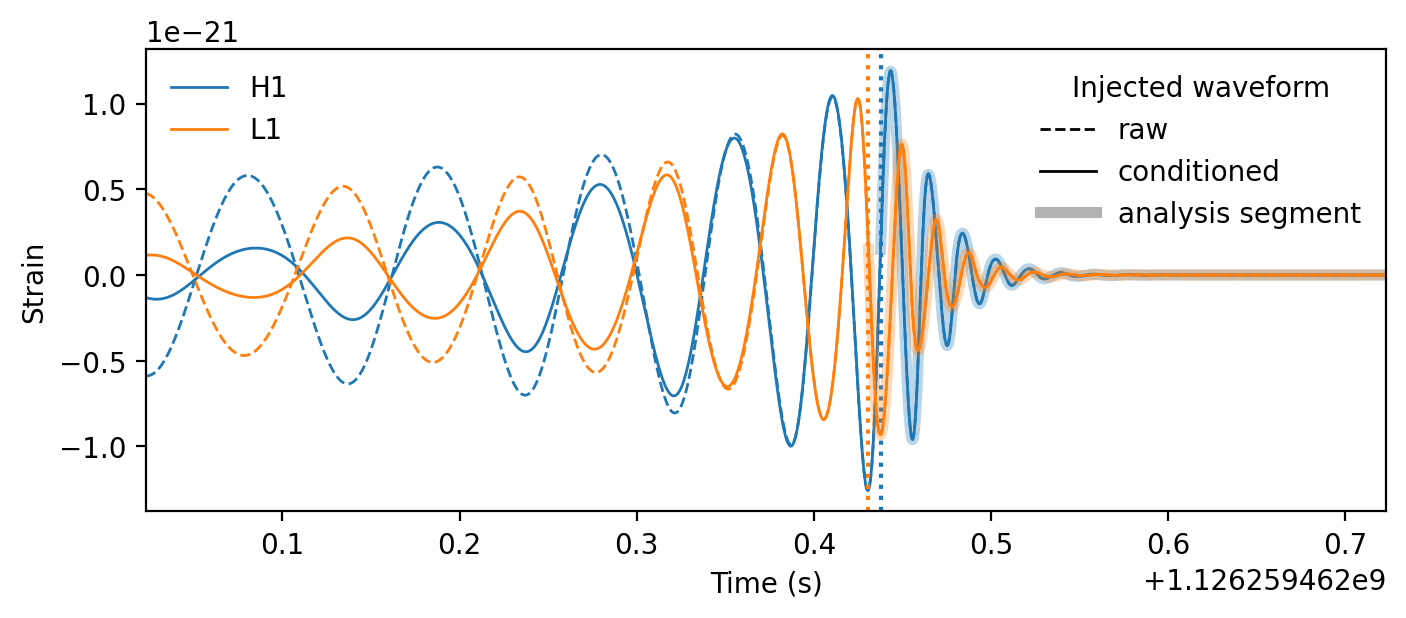

In [37]:
fig, ax = plt.subplots(figsize=(8, 3))

for i, d in fit.data.items():
    l, = ax.plot(d, lw=1, label=i)
    ax.plot(wfs[i], lw=1, ls='--', color=l.get_color())
    ax.plot(fit.analysis_data[i], lw=4, alpha=0.3, color=l.get_color())
    ax.axvline(fit.start_times[i], color=l.get_color(), ls=':')

ax.set_xlim(t0 - 0.4, t0 + 0.3)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Strain')

leg1 = ax.legend(frameon=False, loc='upper left')
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k', lw=1, ls='--'), plt.Line2D([], [], color='k', lw=1), plt.Line2D([], [], color='k', lw=4, alpha=0.3)],
                 ['raw', 'conditioned', 'analysis segment'], frameon=False, loc='upper right', title='Injected waveform')

Shifting waveform such that the analysis segment still begins at the same t0 but only contains ringup:

In [208]:
T = 0.5

In [ ]:
dt = wfs['H1'].index.values[1] - wfs['H1'].index.values[0]
shift = {i: np.arange(wfs[i].index.values[-1], wfs[i].index.values[-1] + T, dt) for i in fit.ifos}
(shift['H1'] == shift['L1']).all()

np.True_

In [ ]:
### shifted time array
index_shift = {i: np.concatenate([wfs[i].index.values[len(shift[i]):], shift[i]]) for i in fit.ifos}

In [ ]:
### same waveform but on shifted time array
wfs_shift = {i: rd.Data(data=wfs[i].values, index=index_shift[i], ifo=i) for i in fit.ifos}

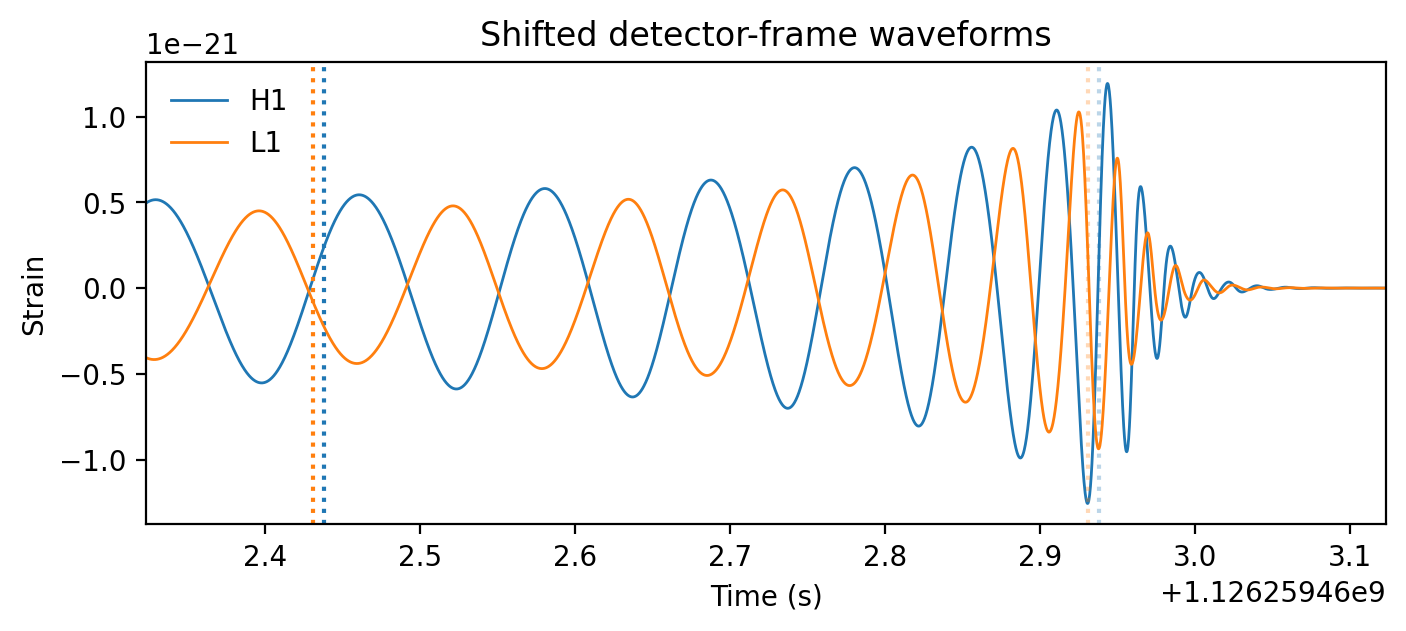

In [212]:
fig, ax = plt.subplots(figsize=(8, 3))

for i, d in wfs_shift.items():
    l, = ax.plot(d, lw=1, label=i)
    # ax.plot(wfs_shift[i], lw=1, ls='--', color=l.get_color())
    # ax.plot(fit.analysis_data[i], lw=4, alpha=0.3, color=l.get_color())
    ax.axvline(fit.start_times[i], color=l.get_color(), ls=':')
    ax.axvline(fit.start_times[i] + T, color=l.get_color(), ls=':', alpha=0.3)

ax.set_xlim(t0 - 0.1, t0 + T + 0.2)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Strain')
ax.set_title('Shifted detector-frame waveforms')

leg1 = ax.legend(frameon=False, loc='upper left')

Save the shifted waveforms to use for ringup-only injection:

In [222]:
for i, wf in wfs_shift.items():
    wf.to_hdf(f'/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot330/SXS_BBH_1155_fmin10Hz_ppSNR20_mtot330_inclined_ringup_{i}.hdf5', key=i)

Check that the analysis segment contains only ringup:

In [224]:
temp_fit = rd.Fit()
temp_fit.set_target(t0=t0, ra=ra, dec=dec, psi=psi, duration=T)
temp_fit.load_data({i: f'/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot330/SXS_BBH_1155_fmin10Hz_ppSNR20_mtot330_inclined_ringup_{i}.hdf5' for i in fit.ifos})

In [225]:
temp_fit.condition_data(f_min=10, ds=1, trim=0)

In [226]:
temp_fit.acfs = fit.acfs.copy()

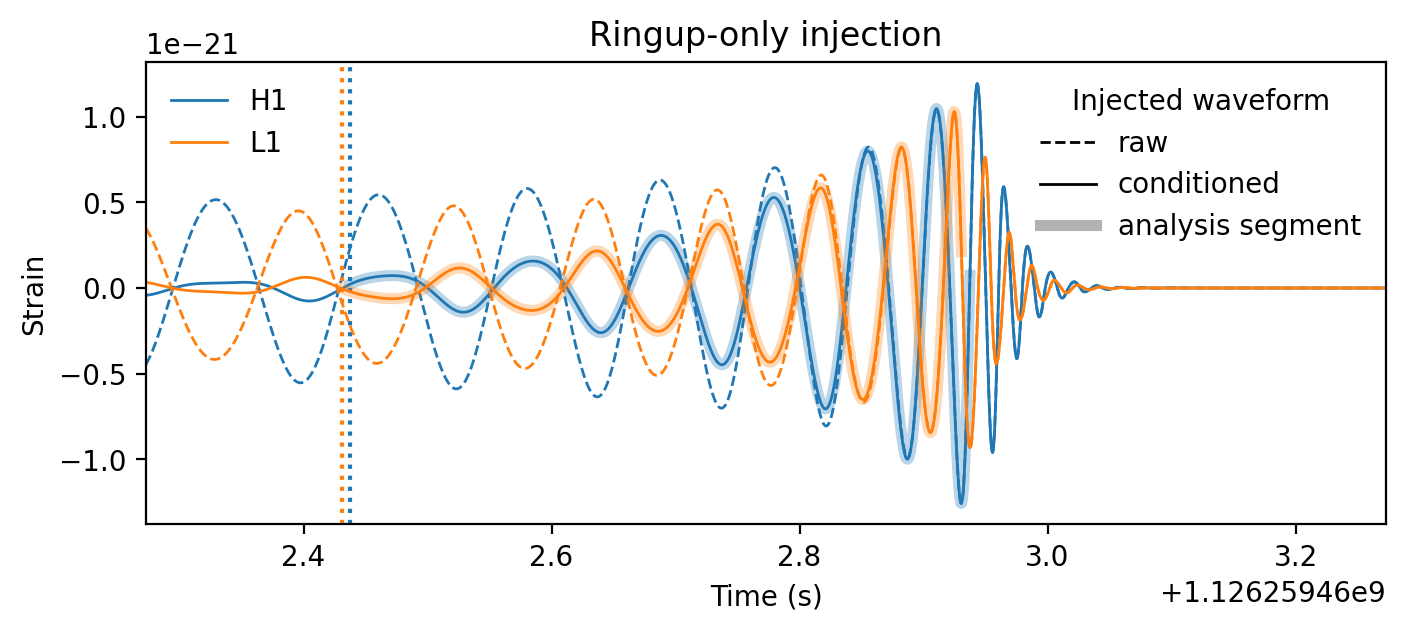

In [227]:
fig, ax = plt.subplots(figsize=(8, 3))

for i, d in temp_fit.data.items():
    l, = ax.plot(d, lw=1, label=i)
    ax.plot(wfs_shift[i], lw=1, ls='--', color=l.get_color())
    ax.plot(temp_fit.analysis_data[i], lw=4, alpha=0.3, color=l.get_color())
    ax.axvline(temp_fit.start_times[i], color=l.get_color(), ls=':')
    # ax.axvline(temp_fit.start_times[i] + T, color=l.get_color(), ls=':', alpha=0.3)

ax.set_xlim(t0 - 0.15, t0 + T + 0.35)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Strain')
ax.set_title('Ringup-only injection')

leg1 = ax.legend(frameon=False, loc='upper left')
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k', lw=1, ls='--'), plt.Line2D([], [], color='k', lw=1), plt.Line2D([], [], color='k', lw=4, alpha=0.3)],
                 ['raw', 'conditioned', 'analysis segment'], frameon=False, loc='upper right', title='Injected waveform')

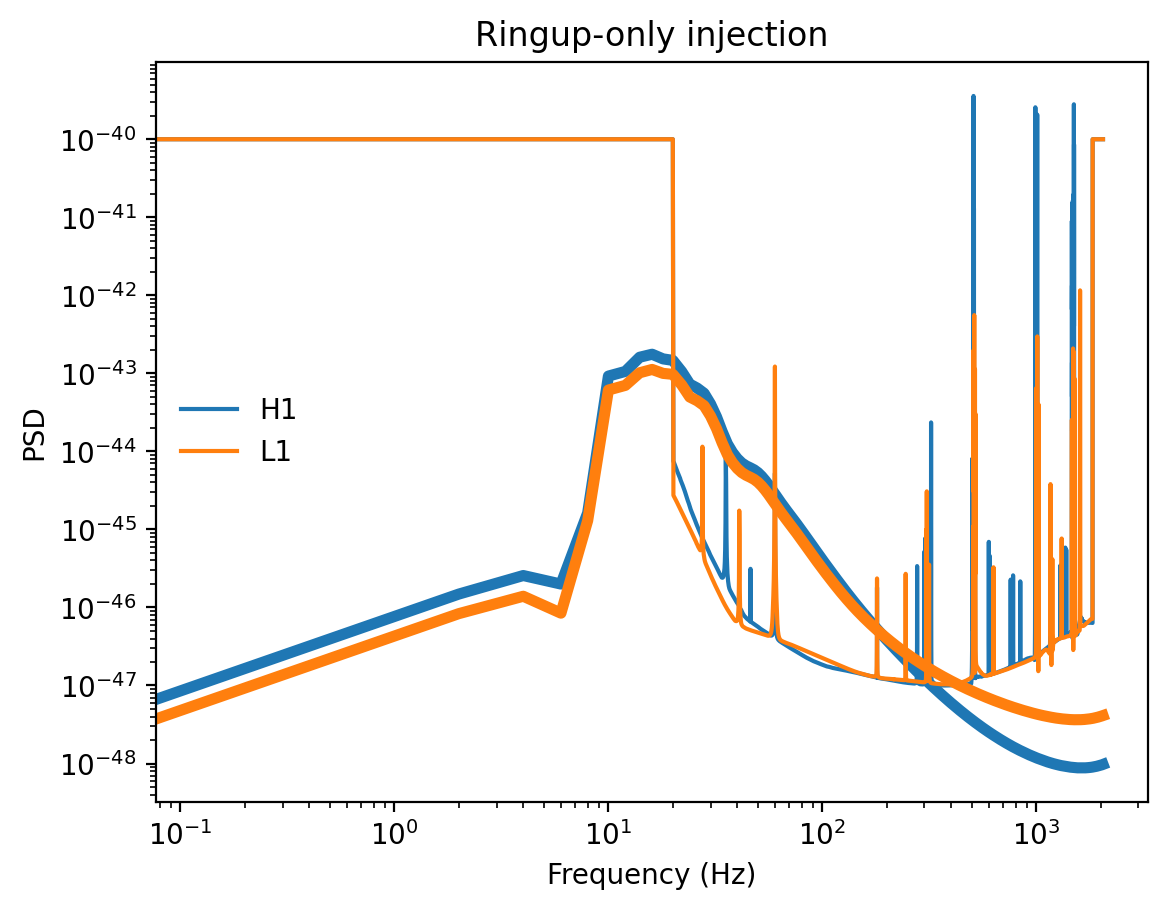

In [231]:
fig, ax = plt.subplots()
for i, psd in temp_fit.psds.items():
    l, = ax.loglog(psd, label=i)
    dt = temp_fit.analysis_data[i].delta_t
    h_freq = np.fft.rfft(temp_fit.analysis_data[i].values)*dt
    fs = np.fft.rfftfreq(len(temp_fit.analysis_data[i].time.values), d=dt)
    ax.loglog(fs, 4*fs*np.abs(h_freq)**2, lw=4, color=l.get_color())
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title('Ringup-only injection')
ax.legend(frameon=False)

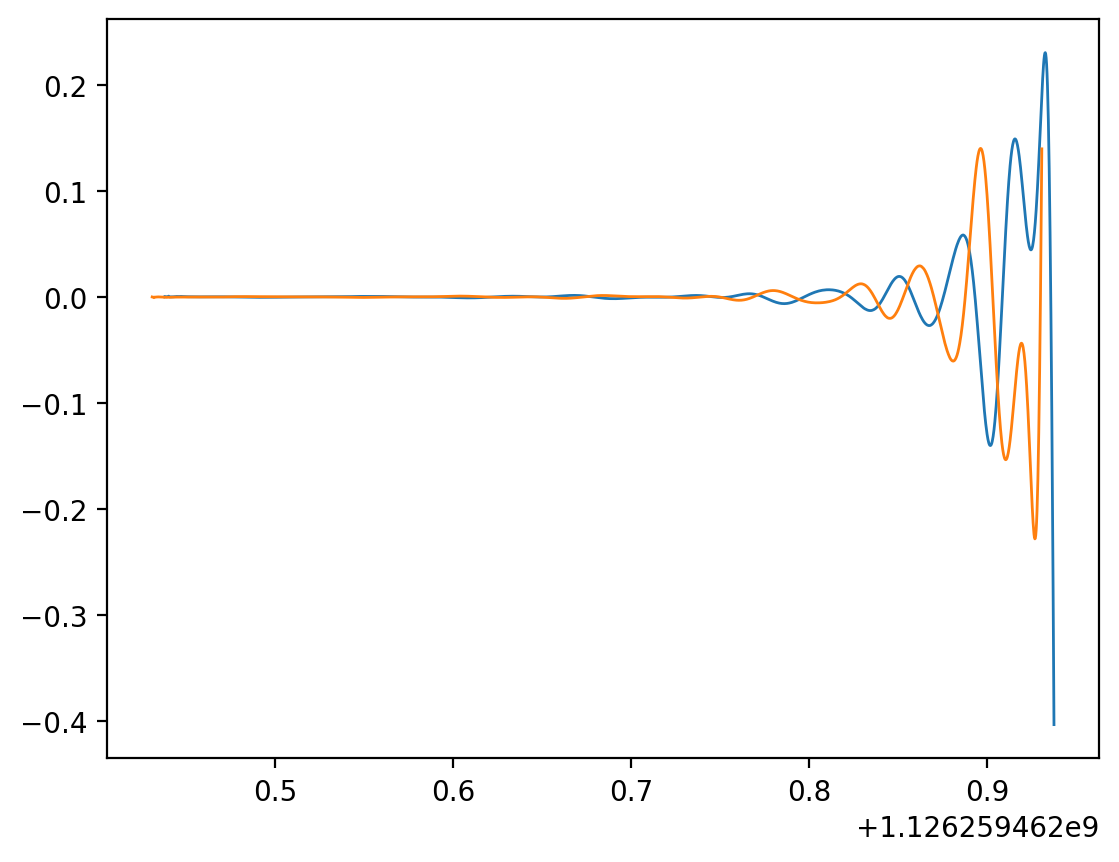

In [229]:
wd = temp_fit.whiten(temp_fit.analysis_data)

for i, d in wd.items():
    plt.plot(d, lw=1, label=i)